# **Caso People Analytics V: Optimización del Time-to-Hire**

Una empresa tecnológica en crecimiento está teniendo dificultades para cubrir sus vacantes en el tiempo esperado.

El Time-to-Hire medio es de 52 días, lo que está generando:

- Retrasos en proyectos

- Sobrecarga en equipos

- Pérdida de candidatos en el proceso

- Mayor coste por contratación

**Objetivos del análisis**

1) Analizar qué factores influyen en el Time-to-Hire.

2) Identificar en qué fases del proceso se generan más retrasos.

3) Construir un modelo que permita predecir cuántos días tardará una vacante en cerrarse.

4) Detectar oportunidades concretas de mejora operativa.

**Qué vamos a analizar:**

a) Trabajaremos con información relacionada con:

b) Tipo de vacante (seniority, área, modalidad remota).

c) Métricas del funnel (días por fase, candidatos descartados).

d) Carga y experiencia del recruiter.

e) Nivel de urgencia de la posición.


El objetivo final no es solo predecir, sino responder a una pregunta clave:

*¿Qué cambios concretos permitirían reducir el Time-to-Hire al menos un 20% sin aumentar el equipo de selección?*

In [1]:
# Importamos las librerias que vamos a utilizar

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

# Configuración visual

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)

In [2]:
url = "https://raw.githubusercontent.com/Pablolg87/people-analytics-case-05-Time-to-Hire-Optimization/refs/heads/main/time_to_hire_raw.csv"

# Cargar datos
employees = pd.read_csv(url)

# Vista inicial
employees.head()

,job_id,job_family,seniority,salary_range,remote_policy,urgency_level,applications_received,cv_screen_days,technical_interview_days,manager_interview_days,offer_approval_days,recruiter_experience_years,open_positions_per_recruiter,time_to_hire_days
0,1,Engineering,Senior,50000-70000,Remote,Medium,84,4.7,24.4,6.4,4.5,5.9,7.7,46.2
1,2,Product,Mid,70000-90000,Remote,Medium,86,5.4,16.9,5.4,7.8,5.4,4.1,33.8
2,3,Data,Mid,40000-50000,Hybrid,High,110,3.3,10.7,10.5,1.2,3.0,5.8,24.8
3,4,Data,Senior,70000-90000,Hybrid,High,134,4.4,17.7,5.3,4.0,5.4,5.4,27.3
4,5,Engineering,Senior,90000-110000,Hybrid,High,156,5.0,5.0,5.9,5.0,7.9,4.0,20.9


**Columnas del dataset**

- job_id: Identificador único de cada vacante.

- job_family: Área funcional de la posición.

- seniority: Nivel de experiencia requerido:

- salary_range: Rango salarial bruto anual ofrecido.

- remote_policy: Modalidad de trabajo (Remote, Hybrid, Onsite).

- urgency_level: Nivel de urgencia de la vacante (High, Medium, Low).

- applications_received: Número total de candidaturas recibidas.

- cv_screen_days: Días dedicados a la fase de revisión de CVs.

- technical_interview_days: Duración de la fase técnica.

- manager_interview_days: Duración de entrevistas con hiring manager.

- offer_approval_days: Tiempo necesario para aprobar la oferta final.

- recruiter_experience_years: Años de experiencia del recruiter asignado.

- open_positions_per_recruiter: Número de vacantes activas que gestiona simultáneamente. Indicador de carga de trabajo.

- time_to_hire_days: Número total de días desde apertura hasta cierre de la vacante *(será nuestro target).*

In [ ]:
# Comprobamos dimensión del dataset

employees.shape

(515, 14)

In [ ]:
# Vemos los tipos de datos

employees.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   job_id                        515 non-null    int64  
 1   job_family                    515 non-null    object 
 2   seniority                     500 non-null    object 
 3   salary_range                  500 non-null    object 
 4   remote_policy                 515 non-null    object 
 5   urgency_level                 515 non-null    object 
 6   applications_received         515 non-null    int64  
 7   cv_screen_days                500 non-null    float64
 8   technical_interview_days      515 non-null    float64
 9   manager_interview_days        515 non-null    float64
 10  offer_approval_days           515 non-null    float64
 11  recruiter_experience_years    515 non-null    object 
 12  open_positions_per_recruiter  515 non-null    float64
 13  time_

In [ ]:
# Vemos valores estadísitcos preliminares con un describe

employees.describe()

,job_id,applications_received,cv_screen_days,technical_interview_days,manager_interview_days,offer_approval_days,open_positions_per_recruiter
count,515.000000,515.000000,500.000000,515.000000,515.000000,515.000000,515.000000
mean,248.320388,119.357282,6.034600,15.066796,7.027573,3.938058,6.017282
std,144.376064,39.330048,1.942248,4.858588,2.084018,1.484521,2.025728
min,1.000000,20.000000,1.000000,5.000000,2.000000,1.000000,1.000000
25%,122.500000,93.000000,4.700000,11.900000,5.500000,2.900000,4.700000
50%,248.000000,119.000000,6.000000,15.000000,7.000000,4.000000,6.000000
75%,372.500000,146.000000,7.400000,18.100000,8.400000,4.900000,7.400000
max,500.000000,247.000000,12.200000,34.600000,12.700000,8.900000,12.200000


"Limpiamos" el dataset:


In [ ]:
# Comprobamos valores nulos

employees.isnull().sum()

,0
job_id,0
job_family,0
seniority,15
salary_range,15
remote_policy,0
urgency_level,0
applications_received,0
cv_screen_days,15
technical_interview_days,0
manager_interview_days,0


In [ ]:
# En porcentaje

null_percentage = (employees.isnull().sum() / len(employees)) * 100
null_percentage.sort_values(ascending=False)

,0
salary_range,2.912621
seniority,2.912621
cv_screen_days,2.912621
time_to_hire_days,2.718447
job_family,0.000000
job_id,0.000000
urgency_level,0.000000
remote_policy,0.000000
technical_interview_days,0.000000
applications_received,0.000000


In [ ]:
# En el caso de valores nulos en "target", vamos a eliminarlos; ya que
# no podemos "inventarnos" eso, así que lo "filtramos"

employees = employees[employees["time_to_hire_days"].notnull()]

employees = employees.copy()

In [ ]:
# Para cv_screen_days vamos a imputar la mediana global

employees["cv_screen_days"] = employees["cv_screen_days"].fillna(
    employees["cv_screen_days"].median()
)

In [ ]:
# Con seniority vamos a crear otra clase llamada "Unknown", para
# evitar sesgos

employees["seniority"] = employees["seniority"].fillna("Unknown")

In [ ]:
# Con salary, vamos a poner la moda según el "seniority"
# Revisamos los valores que tiene cada categoría

employees.groupby("seniority")["salary_range"].value_counts()

seniority  salary_range
Junior     40000-50000     42
           50000-70000     41
           70000-90000     38
           90000-110000    35
Lead       90000-110000    13
           40000-50000     12
           70000-90000      9
           50000-70000      8
Mid        40000-50000     53
           70000-90000     44
           90000-110000    38
           50000-70000     37
Senior     50000-70000     33
           70000-90000     31
           90000-110000    20
           40000-50000     19
Unknown    50000-70000      5
           40000-50000      4
           90000-110000     3
           70000-90000      1
Name: count, dtype: int64

In [ ]:
# Ahora creamos un mapa de salario dominante por seniority

# Para cada nivel de seniority:
# - Eliminamos filas donde salary_range sea nulo
# - Agrupamos por seniority
# - Calculamos el salary_range más frecuente dentro de cada grupo

# Esto nos da el salario "dominante" por nivel.

salary_map = (
    employees
    .dropna(subset=["salary_range"])
    .groupby("seniority")["salary_range"]
    .agg(lambda x: x.value_counts().index[0])
)

In [ ]:
# Ahora imputamos el salario

# Recorremos cada fila del dataset:

# - Si salary_range es nulo, lo reemplazamos por el salario dominante
# correspondiente a su nivel de seniority
# - Si no es nulo, mantenemos el valor original

employees["salary_range"] = employees.apply(
    lambda row: salary_map[row["seniority"]]
    if pd.isnull(row["salary_range"])
    else row["salary_range"],
    axis=1
)

In [ ]:
# Comprobamos que ya no hay nulos

employees.isnull().sum()

,0
job_id,0
job_family,0
seniority,0
salary_range,0
remote_policy,0
urgency_level,0
applications_received,0
cv_screen_days,0
technical_interview_days,0
manager_interview_days,0


In [ ]:
# Revisamos duplicados

employees.duplicated().sum()

np.int64(15)

In [ ]:
# Los revisamos por si acaso

employees[employees.duplicated()].head()

,job_id,job_family,seniority,salary_range,remote_policy,urgency_level,applications_received,cv_screen_days,technical_interview_days,manager_interview_days,offer_approval_days,recruiter_experience_years,open_positions_per_recruiter,time_to_hire_days
500,199,Product,Junior,90000-110000,Hybrid,Low,20,5.7,23.8,8.2,3.1,7.2,8.2,39.8
501,104,Data,Junior,40000-50000,Onsite,High,108,4.8,19.3,3.7,4.5,4.6,10.3,42.3
502,285,Data,Junior,70000-90000,Remote,Medium,74,7.0,24.5,4.3,5.9,1.7,5.1,44.7
503,365,Product,Mid,40000-50000,Hybrid,Low,88,7.1,14.1,8.7,3.9,5.5,8.1,37.4
504,428,Product,Mid,50000-70000,Onsite,Medium,136,7.4,16.0,9.8,2.4,7.1,1.6,34.9


In [ ]:
# Los eliminamos

employees = employees.drop_duplicates(
    subset=employees.columns.difference(["job_id"])
)

employees = employees.copy()

# Revisamos que se han eliminado

employees.duplicated().sum()

np.int64(0)

Ahora haremos alguna transformación más, para asegurarnos de la integridad de los datos:

In [ ]:
# Nos aseguramos que las columnas numéricas tengan valor numérico

numeric_cols = [
    "applications_received",
    "cv_screen_days",
    "technical_interview_days",
    "manager_interview_days",
    "offer_approval_days",
    "recruiter_experience_years",
    "open_positions_per_recruiter",
    "time_to_hire_days"
]

for col in numeric_cols:
    employees[col] = pd.to_numeric(employees[col], errors="coerce")

In [ ]:
# Vemos si hay nuevos nulos

employees[numeric_cols].isnull().sum()

,0
applications_received,0
cv_screen_days,0
technical_interview_days,0
manager_interview_days,0
offer_approval_days,0
recruiter_experience_years,5
open_positions_per_recruiter,0
time_to_hire_days,5


In [ ]:
# Los quitamos

employees = employees.dropna(subset=numeric_cols)
employees = employees.copy()

In [ ]:
# Verificamos el cambio

employees.info()

<class 'pandas.core.frame.DataFrame'>
Index: 476 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   job_id                        476 non-null    int64  
 1   job_family                    476 non-null    object 
 2   seniority                     476 non-null    object 
 3   salary_range                  476 non-null    object 
 4   remote_policy                 476 non-null    object 
 5   urgency_level                 476 non-null    object 
 6   applications_received         476 non-null    int64  
 7   cv_screen_days                476 non-null    float64
 8   technical_interview_days      476 non-null    float64
 9   manager_interview_days        476 non-null    float64
 10  offer_approval_days           476 non-null    float64
 11  recruiter_experience_years    476 non-null    float64
 12  open_positions_per_recruiter  476 non-null    float64
 13  time_to_hi

In [ ]:
# Eliminamos valores negativos en el "target"

employees = employees[employees["time_to_hire_days"] > 0].copy()

In [ ]:
# Convertimos salary_range en numérica

employees["salary_midpoint"] = employees["salary_range"].apply(
    lambda x: (int(x.split("-")[0]) + int(x.split("-")[1])) / 2
)

employees = employees.drop(columns=["salary_range"])

In [ ]:
employees.info()

<class 'pandas.core.frame.DataFrame'>
Index: 472 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   job_id                        472 non-null    int64  
 1   job_family                    472 non-null    object 
 2   seniority                     472 non-null    object 
 3   remote_policy                 472 non-null    object 
 4   urgency_level                 472 non-null    object 
 5   applications_received         472 non-null    int64  
 6   cv_screen_days                472 non-null    float64
 7   technical_interview_days      472 non-null    float64
 8   manager_interview_days        472 non-null    float64
 9   offer_approval_days           472 non-null    float64
 10  recruiter_experience_years    472 non-null    float64
 11  open_positions_per_recruiter  472 non-null    float64
 12  time_to_hire_days             472 non-null    float64
 13  salary_mid

Visualizamos variables:

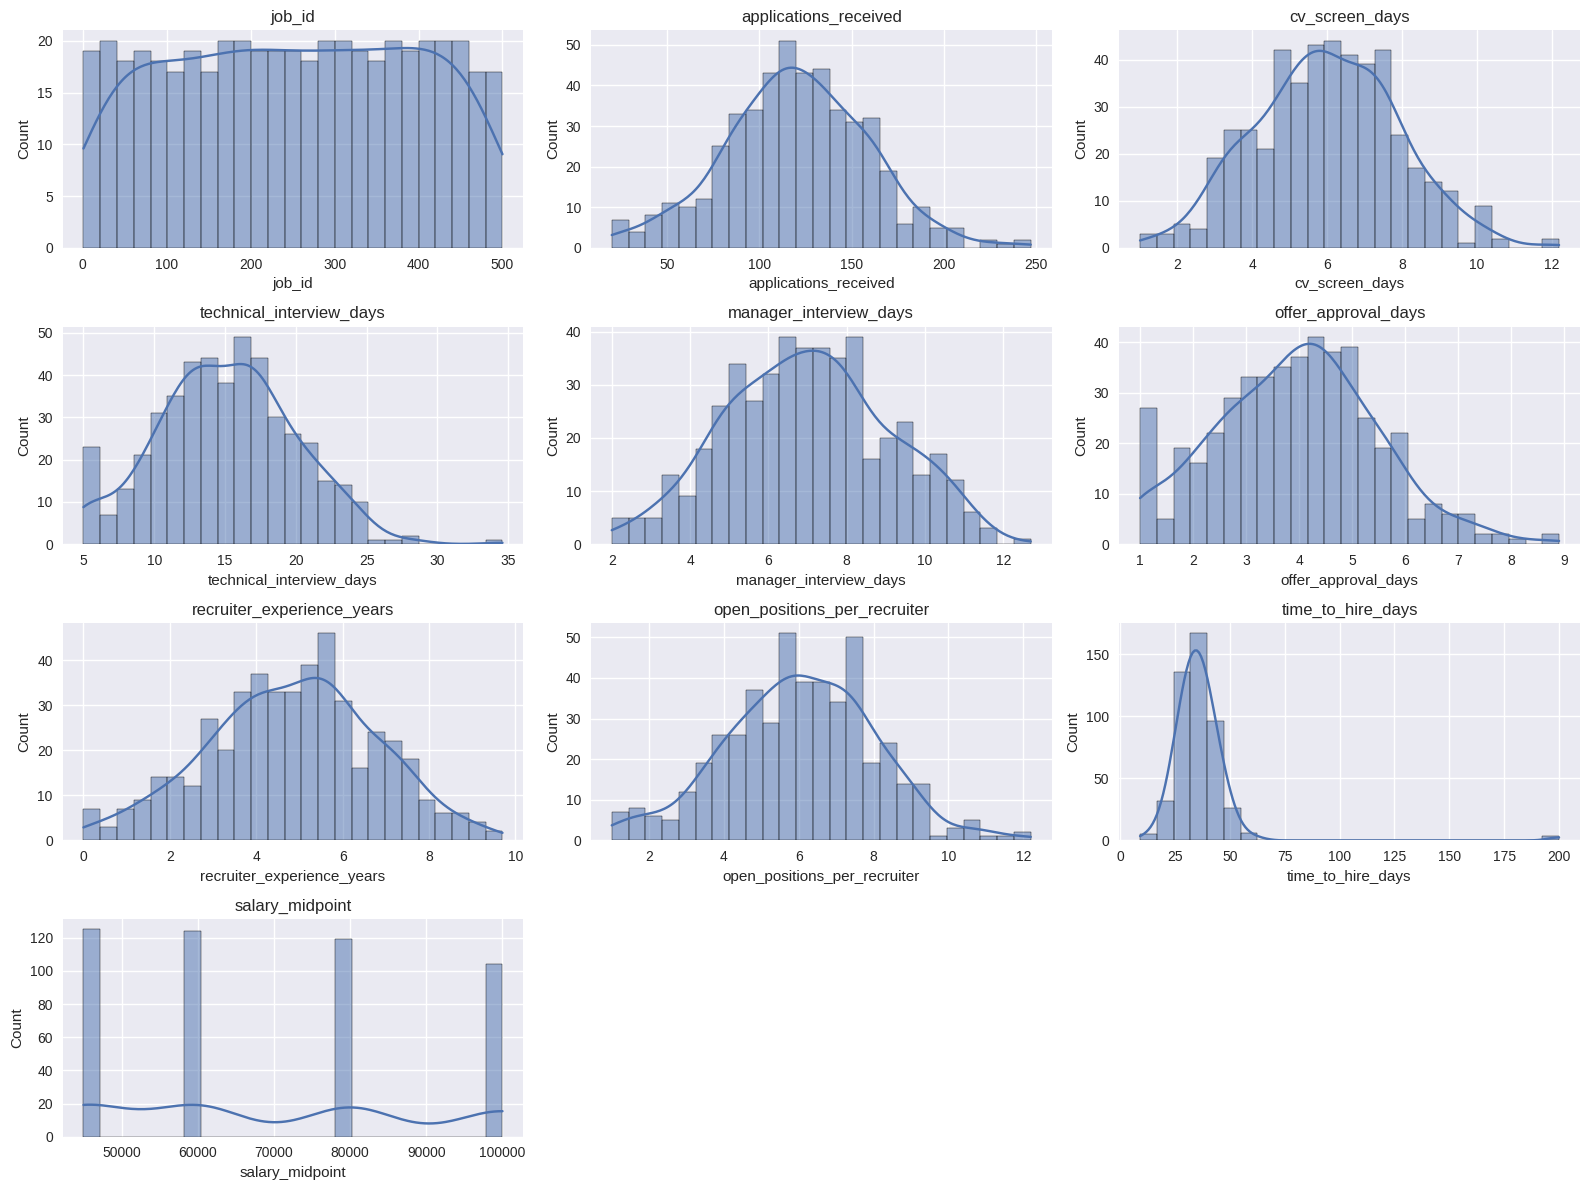

In [ ]:
numeric_cols = employees.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(16, 12))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 3, i)
    sns.histplot(employees[col], bins=25, kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
# Hay un "outlier" en time_to_hire days, lo comprobamos y
# lo eliminamos

employees["time_to_hire_days"].max()

upper_limit = employees["time_to_hire_days"].quantile(0.99)
employees = employees[employees["time_to_hire_days"] <= upper_limit].copy()

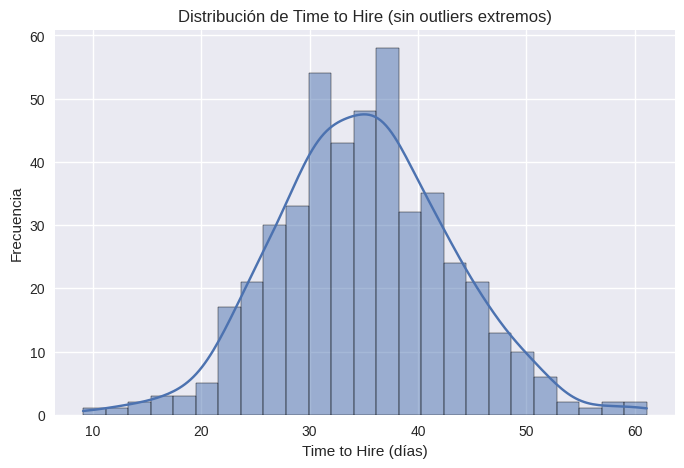

In [ ]:
# Volvemos a verla para comprobar el cambio

plt.figure(figsize=(8,5))
sns.histplot(employees["time_to_hire_days"], bins=25, kde=True)

plt.title("Distribución de Time to Hire (sin outliers extremos)")
plt.xlabel("Time to Hire (días)")
plt.ylabel("Frecuencia")

plt.show()

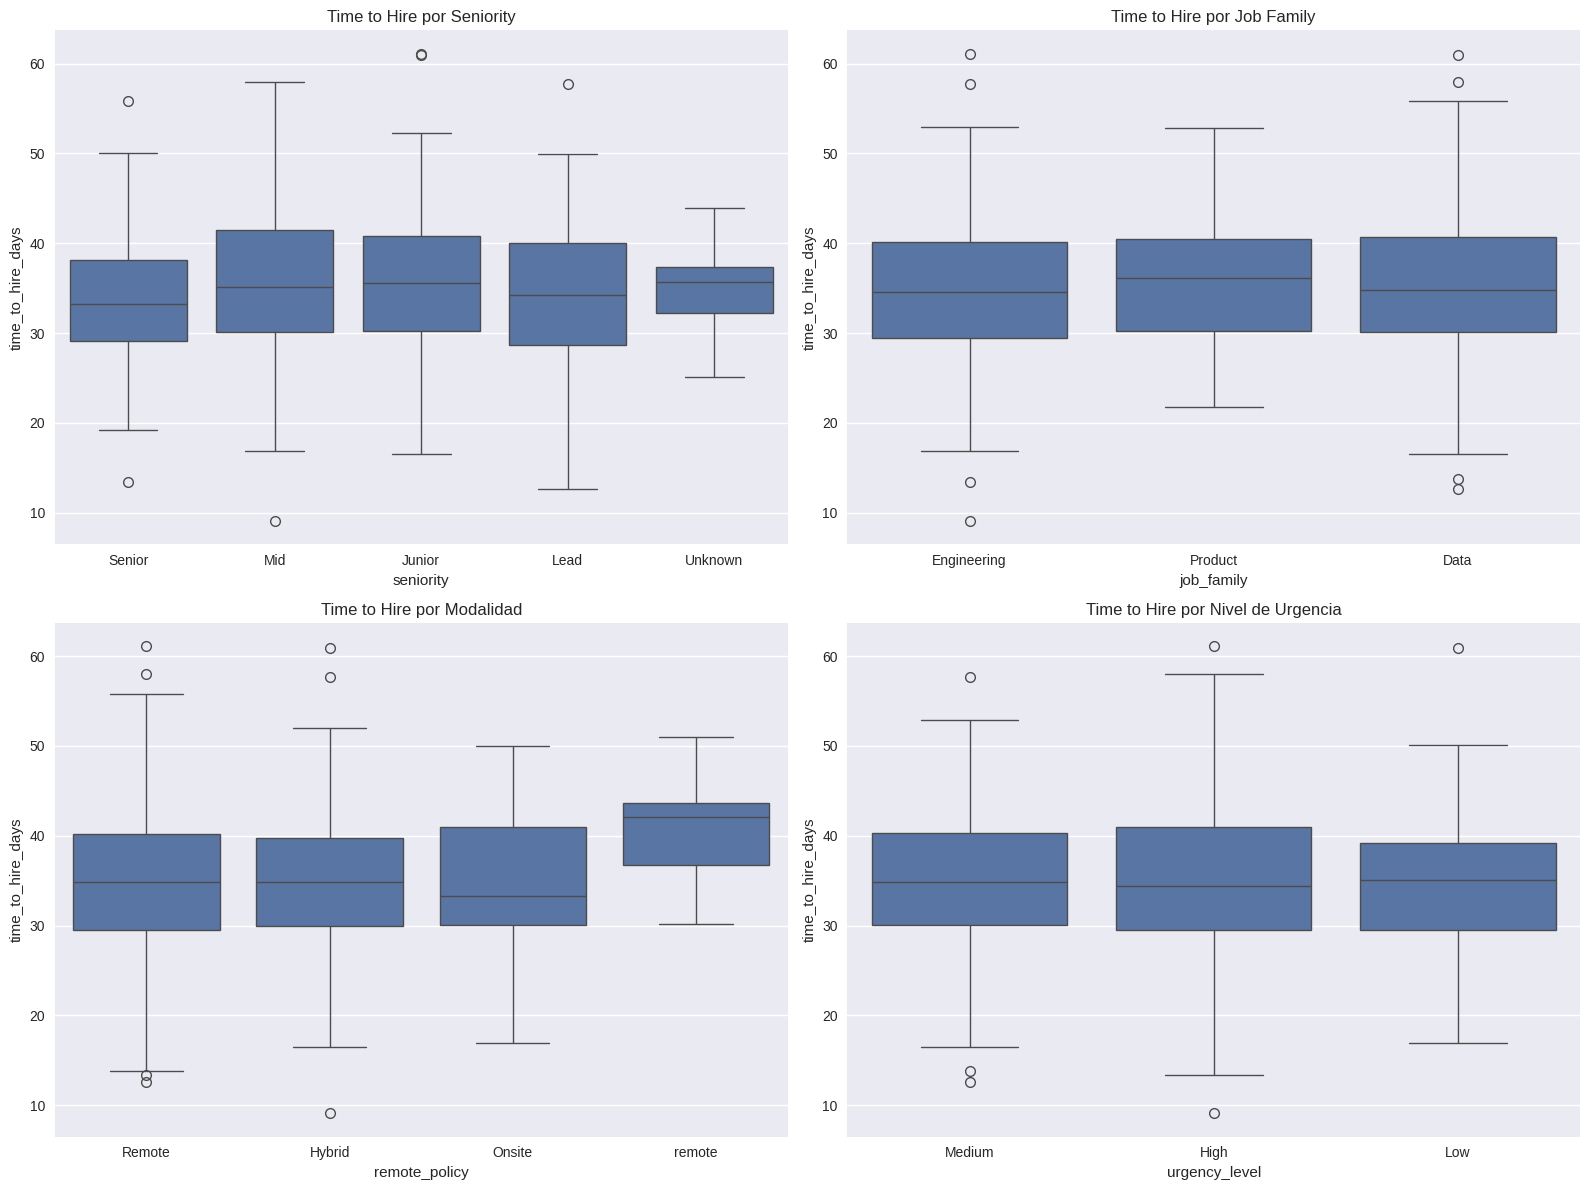

In [ ]:
# impacto de variables categóricas sobre el Time-to-Hire


plt.figure(figsize=(16,12))

# Seniority
plt.subplot(2,2,1)
sns.boxplot(x="seniority", y="time_to_hire_days", data=employees)
plt.title("Time to Hire por Seniority")

# Job Family
plt.subplot(2,2,2)
sns.boxplot(x="job_family", y="time_to_hire_days", data=employees)
plt.title("Time to Hire por Job Family")

# Remote Policy
plt.subplot(2,2,3)
sns.boxplot(x="remote_policy", y="time_to_hire_days", data=employees)
plt.title("Time to Hire por Modalidad")

# Urgency Level
plt.subplot(2,2,4)
sns.boxplot(x="urgency_level", y="time_to_hire_days", data=employees)
plt.title("Time to Hire por Nivel de Urgencia")

plt.tight_layout()
plt.show()

In [ ]:
# Detectamos un fallo en remote_policy, lo comprobamos

employees["remote_policy"].value_counts()

,count
remote_policy,
Remote,249
Hybrid,160
Onsite,49
remote,9


In [ ]:
# Lo arreglamos

employees["remote_policy"] = employees["remote_policy"].str.capitalize()

# Re-visualizamos

employees["remote_policy"].value_counts()

,count
remote_policy,
Remote,258
Hybrid,160
Onsite,49


# **Conclusiones del análisis exploratorio (EDA)**

Tras limpiar y visualizar el dataset, podemos extraer algunas conclusiones clave:

- La distribución del Time-to-Hire es estable y aproximadamente normal, con la mayoría de procesos cerrándose entre 30 y 45 días.

- No se observan diferencias muy marcadas en el tiempo de contratación según seniority, área o nivel de urgencia.

- La modalidad de trabajo (Remote, Hybrid, Onsite) tampoco muestra un impacto estructural fuerte.

Esto sugiere que **el Time-to-Hire parece estar más influido por variables operativas del proceso** (duración de fases, carga del recruiter, etc.) **que por características estructurales de la vacante.**

**Revisamosmos correlaciones de variable con un Heatmap:**

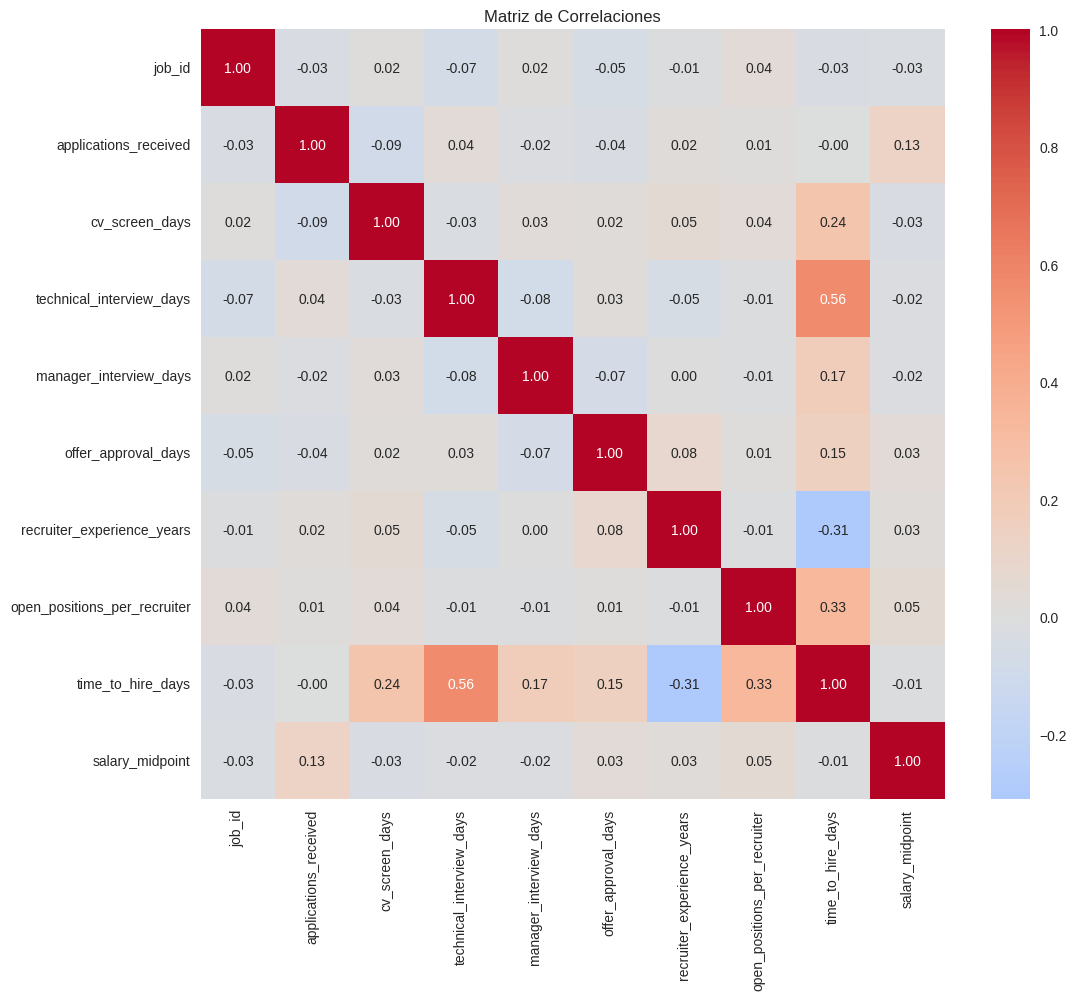

In [ ]:
# Se analiza la relación lineal entre métricas operativas y el Time-to-Hire

# Matriz de correlación
corr_matrix = employees.corr(numeric_only=True)

plt.figure(figsize=(12,10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de Correlaciones")
plt.show()

# **Conclusiones del Mapa de Correlaciones**

El **Time-to-Hire** está *principalmente influido por la duración de la fase técnica. *

Cuanto **más se alarga esa fase, más tarda en cerrarse la vacante.**

**La carga de trabajo del recruiter también impacta**: cuantos más procesos lleva simultáneamente, mayor es el tiempo de cierre.

La **experiencia del recruiter ayuda a reducir el tiempo de contratación.**

Variables como área, seniority o urgencia no parecen tener un impacto fuerte en comparación con los factores operativos.

En resumen, **el tiempo de contratación depende más de cómo se gestiona el proceso que de las características de la vacante en sí.**

# **Modelo predictivo de Time-to-Hire**

En esta fase vamos a construir un **modelo sencillo de Machine Learning para predecir el Time-to-Hire de una vacante.**

El modelo **utilizará las variables operativas del proceso** (duración de fases, carga del recruiter, experiencia, etc.) para **estimar cuántos días tardará en cerrarse una posición.**


- Entrenaremos un modelo de tipo Random Forest, que es robusto y funciona bien con relaciones no lineales.

- Evaluaremos el error medio en días para entender qué tan precisa es la predicción.

- Analizaremos qué variables influyen más en el resultado.

In [ ]:
# Preparación del dataset para ML

# - Definir X (variables predictoras) e y (target)
# - Quedarnos con variables numéricas para un modelo sencillo
# - Eliminar columnas que no aportan (job_id) y el target

# Features (quitamos target y el identificador)
X = employees.drop(columns=["time_to_hire_days", "job_id"])

# Target
y = employees["time_to_hire_days"]

# One-hot encoding de categóricas (job_family, seniority, remote_policy, urgency_level)
X = pd.get_dummies(X, drop_first=True)

# Comprobación rápida
print("Shape X:", X.shape)
print("Shape y:", y.shape)
X.head()

Shape X: (467, 18)
Shape y: (467,)


,applications_received,cv_screen_days,technical_interview_days,manager_interview_days,offer_approval_days,recruiter_experience_years,open_positions_per_recruiter,salary_midpoint,job_family_Engineering,job_family_Product,seniority_Lead,seniority_Mid,seniority_Senior,seniority_Unknown,remote_policy_Onsite,remote_policy_Remote,urgency_level_Low,urgency_level_Medium
0,84,4.7,24.4,6.4,4.5,5.9,7.7,60000.0,True,False,False,False,True,False,False,True,False,True
1,86,5.4,16.9,5.4,7.8,5.4,4.1,80000.0,False,True,False,True,False,False,False,True,False,True
2,110,3.3,10.7,10.5,1.2,3.0,5.8,45000.0,False,False,False,True,False,False,False,False,False,False
3,134,4.4,17.7,5.3,4.0,5.4,5.4,80000.0,False,False,False,False,True,False,False,False,False,False
4,156,5.0,5.0,5.9,5.0,7.9,4.0,100000.0,True,False,False,False,True,False,False,False,False,False


In [ ]:
#Train/Test Split

# - Separar datos en entrenamiento (para aprender patrones)
#   y test (para evaluar rendimiento en datos no vistos)

# - 80% train / 20% test es estándar en este tipo de casos

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (373, 18) (373,)
Test : (94, 18) (94,)


In [ ]:
# Entrenamiento del Random Forest

# - Entrena muchos "árboles de decisión" sobre distintas muestras del dataset
# - Promedia sus predicciones para obtener un resultado estable
# - Captura relaciones no lineales (ej. saturación de recruiters)
# - No requiere escalado de variables
# - Suele funcionar bien como baseline en regresión

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
# Métricas
# - MAE (Mean Absolute Error): error medio en días.
# - R²: porcentaje de variación del target que explica el modelo.

from sklearn.metrics import mean_absolute_error, r2_score

# Predicción sobre el conjunto de test
y_pred = model.predict(X_test)

# Métricas
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE (error medio en días):", round(mae, 2))
print("R² (capacidad explicativa):", round(r2, 3))

MAE (error medio en días): 4.4
R² (capacidad explicativa): 0.504


El **modelo explica aproximadamente el 50% del tiempo de contratación.**

Esto significa que:

- La **mitad del Time-to-Hire se puede anticipar con las variables del proceso** (duración de fases, carga del recruiter, etc.).

- La **otra mitad depende de factores que no están en el dataset**, como decisiones humanas, contexto del mercado o situaciones puntuales.

- Un **error medio de 4,4 días es razonable** si el proceso medio dura unos 35–40 días.

No es perfecto, pero sí **útil para planificación y mejora operativa.**


**En resumen:**
El modelo no predice todo, pero sí capta los principales factores que influyen en el tiempo de contratación.

In [ ]:
# Vemos que variables son más importantes en el modelo

importances = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances.head(10)

,0
technical_interview_days,0.368421
open_positions_per_recruiter,0.160843
recruiter_experience_years,0.145422
cv_screen_days,0.099859
manager_interview_days,0.066485
offer_approval_days,0.052484
applications_received,0.041395
salary_midpoint,0.016235
remote_policy_Remote,0.007377
seniority_Mid,0.006465


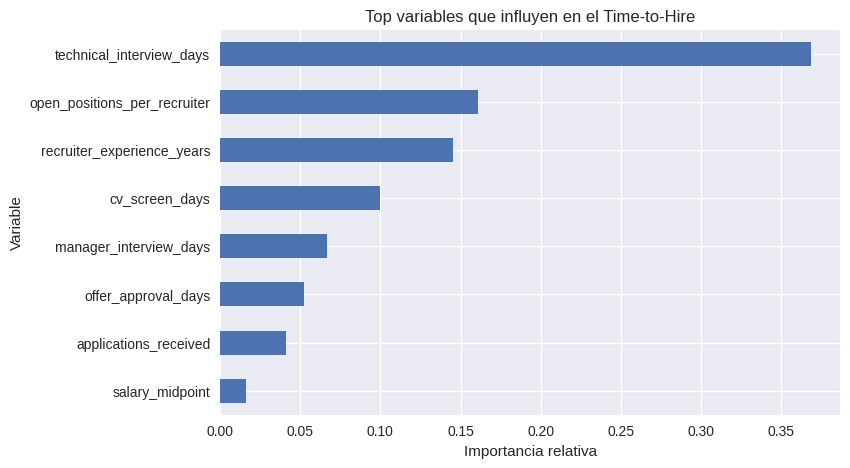

In [ ]:
# Mostramos gráficamente las 8 variables que más influyen
# en la predicción

top_features = importances.head(8).sort_values()

plt.figure(figsize=(8,5))
top_features.plot(kind="barh")
plt.title("Top variables que influyen en el Time-to-Hire")
plt.xlabel("Importancia relativa")
plt.ylabel("Variable")
plt.show()

# **Conclusión final**

El **modelo predice el Time-to-Hire con un error medio de unos 4 días y explica aproximadamente el 50% del tiempo de contratación.**

Esto indica que **existen factores operativos claros que influyen en el proceso**, especialmente la duración de las fases y la carga del recruiter.

Aunque no explica todo, **el modelo es útil para anticipar tiempos y mejorar la gestión del proceso de selección.**